# Chain Model Training with K-Fold - US Traffic Incident Analysis
ในขั้นตอนนี้เราจะเพิ่มการทำ **K-Fold Cross-Validation** เพื่อให้มั่นใจว่า Model ของเรามีความแม่นยำและเสถียร (Robust) ไม่ว่าจะสุ่มข้อมูลส่วนไหนมา Train ก็ตาม

In [1]:
%pip install pandas numpy matplotlib seaborn joblib scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# ===== Training knobs =====
USE_LOG_TARGET   = True   # log1p targets — both Distance & Duration are heavy-tailed
N_ESTIMATORS_MAX = 3000   # let early stopping decide; previous run capped at 500
LR               = 0.03
MAX_DEPTH        = 8
EARLY_STOP       = 50
N_OOF_FOLDS      = 5      # K-Fold for out-of-fold distance predictions (chain training)


## 1. Load Data

In [3]:
df_train = pd.read_csv("../data/processed/03/train_features.csv")

# Bool columns from CSV stay as bool dtype — cast to int so XGBoost treats them as numeric
bool_cols = df_train.select_dtypes(include='bool').columns.tolist()
df_train[bool_cols] = df_train[bool_cols].astype(int)

print(f"Shape : {df_train.shape[0]:,} rows × {df_train.shape[1]} cols")
print(f"Bool→int : {bool_cols}")
df_train.head(3)

Shape : 5,469,092 rows × 61 cols
Bool→int : ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal']


,Severity,Start_Time,Start_Lat,Start_Lng,Distance(mi),Description,Street,City,County,State,...,Road_Complexity,Is_Intersection,Is_Controlled,State_Freq,City_Freq,is_shoulder,is_blocked,is_overturned,Rush_x_Severity,Night_x_Severity
0,3,2016-11-08 08:50:37,29.718655,-95.32105,0.00995,Accident on I-45 Northbound at I-45 Exits 43A ...,I-45 N,Houston,Harris,TX,...,1.098612,0.693147,0.693147,0.280078,0.022795,0.000000,0.000000,0.0,1.732051,0.0
1,2,2021-07-26 07:04:56,38.927550,-121.08009,0.00000,Right hand shoulder blocked due to accident on...,Taylor Ln,Auburn,Placer,CA,...,0.693147,0.000000,0.693147,0.473334,0.000813,0.693147,0.693147,0.0,1.414214,0.0
2,2,2018-10-24 08:23:38,34.776240,-86.67283,0.00000,Lane blocked due to accident on AL-255 Researc...,Highway 255,Huntsville,Madison,AL,...,0.000000,0.000000,0.000000,0.117871,0.001156,0.000000,0.693147,0.0,1.414214,0.0


## 2. Configuration & Features

In [4]:
TARGET_DIST = "Distance(mi)"
TARGET_DUR  = "Duration(min)"

# All text/categorical columns were encoded in feature engineering — nothing to one-hot
base_features = [c for c in df_train.columns if c not in [TARGET_DIST, TARGET_DUR]]
X_base        = df_train[base_features]

num_features = X_base.select_dtypes(include='number').columns.tolist()
cat_features = []   # already encoded in 03_feature_engineering

print(f"Base features : {len(base_features)}")
print(f"  Numerical   : {len(num_features)}  (cat=0, all encoded already)")
print(f"\n{num_features}")

Base features : 59
  Numerical   : 45  (cat=0, all encoded already)

['Severity', 'Start_Lat', 'Start_Lng', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Hour', 'Month', 'DayOfWeek', 'Is_Rush_Hour', 'Is_Weekend', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'Is_Night', 'Is_Bad_Weather', 'Low_Visibility_Flag', 'Freezing_Flag', 'Weather_Risk_Score', 'Road_Complexity', 'Is_Intersection', 'Is_Controlled', 'State_Freq', 'City_Freq', 'is_shoulder', 'is_blocked', 'is_overturned', 'Rush_x_Severity', 'Night_x_Severity']


## 3. K-Fold Cross-Validation Setup
เราจะใช้ 5-Fold Cross-Validation เพื่อทดสอบประสิทธิภาพ

In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def run_kfold_cv(model, X, y, name):
    print(f"Running 5-Fold CV for {name}...")
    # เพื่อความรวดเร็วในการรัน K-Fold กับข้อมูล 5 ล้านแถว 
    # จะขอสุ่มมาใช้เพียง 10% (5 แสนแถว) สำหรับการทำ CV
    sample_idx = np.random.choice(len(X), int(len(X)*0.1), replace=False)
    X_sample = X.iloc[sample_idx]
    y_sample = y.iloc[sample_idx]
    
    scores = cross_val_score(model, X_sample, y_sample, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
    mae_scores = -scores
    print(f"{name} CV MAE: {mae_scores.mean():.4f} (+/- {mae_scores.std():.4f})")
    return mae_scores

Training Model 1 (Distance) — up to 3000 rounds, lr=0.03, depth=8, log_target=True...
[0]	validation_0-mae:0.21496
[100]	validation_0-mae:0.17436
[200]	validation_0-mae:0.16852
[300]	validation_0-mae:0.16590
[400]	validation_0-mae:0.16388
[500]	validation_0-mae:0.16220
[600]	validation_0-mae:0.16097
[700]	validation_0-mae:0.16001
[800]	validation_0-mae:0.15924
[900]	validation_0-mae:0.15852
[1000]	validation_0-mae:0.15790
[1100]	validation_0-mae:0.15740
[1200]	validation_0-mae:0.15691
[1300]	validation_0-mae:0.15642
[1400]	validation_0-mae:0.15597
[1500]	validation_0-mae:0.15559
[1600]	validation_0-mae:0.15524
[1700]	validation_0-mae:0.15492
[1800]	validation_0-mae:0.15462
[1900]	validation_0-mae:0.15434
[2000]	validation_0-mae:0.15407
[2100]	validation_0-mae:0.15382
[2200]	validation_0-mae:0.15358
[2300]	validation_0-mae:0.15334
[2400]	validation_0-mae:0.15312
[2500]	validation_0-mae:0.15294
[2600]	validation_0-mae:0.15274
[2700]	validation_0-mae:0.15255
[2800]	validation_0-mae:0.1523

## 4. Model 1 (Distance) with CV

In [ ]:
y_distance = df_train[TARGET_DIST]

# Split — save indices so Model 2 uses the exact same rows
X_train_d, X_val_d, y_train_d, y_val_d = train_test_split(
    X_base, y_distance, test_size=0.2, random_state=42
)
TRAIN_IDX = X_train_d.index
VAL_IDX   = X_val_d.index

# Heavy-tailed target → fit in log1p space, invert with expm1 at predict time
y_train_d_t = np.log1p(y_train_d) if USE_LOG_TARGET else y_train_d
y_val_d_t   = np.log1p(y_val_d)   if USE_LOG_TARGET else y_val_d

# Select numeric features as float32 — XGBoost (hist) handles NaN natively,
# and tree models are scale-invariant so no StandardScaler/Imputer needed.
X_tr_d      = X_train_d[num_features].astype('float32')
X_vl_d_proc = X_val_d[num_features].astype('float32')

# XGBoost — train MORE rounds with lower lr, deeper trees, patient early stopping
xgb_dist = XGBRegressor(
    n_estimators        = N_ESTIMATORS_MAX,
    learning_rate       = LR,
    max_depth           = MAX_DEPTH,
    min_child_weight    = 5,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    reg_alpha           = 0.1,
    reg_lambda          = 1.0,
    random_state        = 42,
    tree_method         = 'hist',
    early_stopping_rounds = EARLY_STOP,
    eval_metric         = 'mae',
    n_jobs              = -1,
)

print(f"Training Model 1 (Distance) — up to {N_ESTIMATORS_MAX} rounds, lr={LR}, depth={MAX_DEPTH}, log_target={USE_LOG_TARGET}...")
xgb_dist.fit(
    X_tr_d, y_train_d_t,
    eval_set=[(X_vl_d_proc, y_val_d_t)],
    verbose=100
)

# Wrap into a Pipeline for consistent .predict(X_raw[num_features].astype('float32')) interface
model_dist = Pipeline([('regressor', xgb_dist)])

# Predict in log space → invert to mile space for honest metrics
pred_d_log = xgb_dist.predict(X_vl_d_proc)
pred_d     = np.expm1(pred_d_log) if USE_LOG_TARGET else pred_d_log
pred_d     = np.clip(pred_d, 0, None)   # distance can't be negative

print(f"\n=== Model 1 — Distance Predictor (validation, original scale) ===")
print(f"  MAE       : {mean_absolute_error(y_val_d, pred_d):.4f}")
print(f"  RMSE      : {np.sqrt(mean_squared_error(y_val_d, pred_d)):.4f}")
print(f"  R²        : {r2_score(y_val_d, pred_d):.4f}")
print(f"  Best iter : {xgb_dist.best_iteration}  (cap={N_ESTIMATORS_MAX})")

### 3.1 Out-of-Fold Distance for Chain Training

ปัญหาเดิม: Model 2 train ด้วย **ground-truth Distance** แต่ตอน inference เห็น **predicted Distance** จาก Model 1 → distribution mismatch (chain R² ติดลบ).

วิธีแก้: ทำ K-Fold OOF prediction บน train set เพื่อให้ Model 2 train บน distance ที่ "เหมือนของจริงตอน inference" → ลด chain MAE ได้มาก (ยังคงเป็น chain method เดิม).


In [6]:
# K-Fold OOF distance predictions on TRAIN rows.
# Each row's distance is predicted by a model that has NEVER seen that row → no leak.
kf = KFold(n_splits=N_OOF_FOLDS, shuffle=True, random_state=42)
oof_dist = np.zeros(len(X_train_d), dtype=float)

# XGB params for fold models (same as Model 1, lighter early stop to save time)
fold_params = dict(
    n_estimators        = N_ESTIMATORS_MAX,
    learning_rate       = LR,
    max_depth           = MAX_DEPTH,
    min_child_weight    = 5,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    reg_alpha           = 0.1,
    reg_lambda          = 1.0,
    random_state        = 42,
    tree_method         = 'hist',
    early_stopping_rounds = EARLY_STOP,
    eval_metric         = 'mae',
    n_jobs              = -1,
)

print(f"Generating OOF distance predictions ({N_OOF_FOLDS}-fold)...")
for fold, (tr_pos, va_pos) in enumerate(kf.split(X_train_d), 1):
    X_fold_tr_p = X_train_d.iloc[tr_pos][num_features].astype('float32')
    X_fold_va_p = X_train_d.iloc[va_pos][num_features].astype('float32')
    y_fold_tr   = y_train_d.iloc[tr_pos]
    y_fold_va   = y_train_d.iloc[va_pos]

    y_fold_tr_t = np.log1p(y_fold_tr) if USE_LOG_TARGET else y_fold_tr
    y_fold_va_t = np.log1p(y_fold_va) if USE_LOG_TARGET else y_fold_va

    m = XGBRegressor(**fold_params)
    m.fit(X_fold_tr_p, y_fold_tr_t,
          eval_set=[(X_fold_va_p, y_fold_va_t)], verbose=False)
    pred_va = m.predict(X_fold_va_p)
    if USE_LOG_TARGET:
        pred_va = np.expm1(pred_va)
    oof_dist[va_pos] = np.clip(pred_va, 0, None)
    print(f"  fold {fold}/{N_OOF_FOLDS} — best_iter={m.best_iteration}, "
          f"MAE={mean_absolute_error(y_fold_va, oof_dist[va_pos]):.4f}")

oof_mae = mean_absolute_error(y_train_d, oof_dist)
print(f"\nOOF distance MAE on full train: {oof_mae:.4f}  "
      f"(val MAE was {mean_absolute_error(y_val_d, pred_d):.4f})")

Generating OOF distance predictions (5-fold)...
  fold 1/5 — best_iter=2999, MAE=0.2168
  fold 2/5 — best_iter=2999, MAE=0.2173
  fold 3/5 — best_iter=2999, MAE=0.2162
  fold 4/5 — best_iter=2999, MAE=0.2167
  fold 5/5 — best_iter=2999, MAE=0.2164

OOF distance MAE on full train: 0.2167  (val MAE was 0.2165)


## 5. Model 2 (Duration) with CV

In [7]:
y_duration = df_train[TARGET_DUR]

# Model 2 needs Distance(mi) as an extra feature
num_features_dur = num_features + [TARGET_DIST]

# *** KEY CHANGE ***  Train uses OOF predicted distance (matches inference dist),
#                     not ground-truth distance. This kills the chain R² collapse.
X_train_t = X_base.loc[TRAIN_IDX].copy()
X_train_t[TARGET_DIST] = oof_dist                      # <-- predicted, not GT

# Oracle val: GT Distance (upper bound)
X_val_oracle              = X_base.loc[VAL_IDX].copy()
X_val_oracle[TARGET_DIST] = df_train.loc[VAL_IDX, TARGET_DIST]

# Chain val: Model 1 prediction (realistic inference)
X_val_chain               = X_val_d.copy()
X_val_chain[TARGET_DIST]  = pred_d

y_train_t = y_duration.loc[TRAIN_IDX]
y_val_t   = y_duration.loc[VAL_IDX]

# Log-transform duration if enabled
y_train_t_log = np.log1p(y_train_t) if USE_LOG_TARGET else y_train_t
y_val_t_log   = np.log1p(y_val_t)   if USE_LOG_TARGET else y_val_t

# Select numeric features as float32 — XGBoost (hist) handles NaN natively
X_tr_t      = X_train_t[num_features_dur].astype('float32')
X_vl_oracle = X_val_oracle[num_features_dur].astype('float32')
X_vl_chain  = X_val_chain[num_features_dur].astype('float32')

xgb_dur = XGBRegressor(
    n_estimators        = N_ESTIMATORS_MAX,
    learning_rate       = LR,
    max_depth           = MAX_DEPTH,
    min_child_weight    = 5,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    reg_alpha           = 0.1,
    reg_lambda          = 1.0,
    random_state        = 42,
    tree_method         = 'hist',
    early_stopping_rounds = EARLY_STOP,
    eval_metric         = 'mae',
    n_jobs              = -1,
)

print(f"Training Model 2 (Duration) on OOF distance — up to {N_ESTIMATORS_MAX} rounds...")
# Early-stop on the CHAIN val (the realistic deployment scenario), not oracle
xgb_dur.fit(
    X_tr_t, y_train_t_log,
    eval_set=[(X_vl_chain, y_val_t_log)],
    verbose=100
)

model_dur = Pipeline([('regressor', xgb_dur)])

pred_dur_oracle_log = xgb_dur.predict(X_vl_oracle)
pred_dur_chain_log  = xgb_dur.predict(X_vl_chain)
if USE_LOG_TARGET:
    pred_dur_oracle = np.clip(np.expm1(pred_dur_oracle_log), 0, None)
    pred_dur_chain  = np.clip(np.expm1(pred_dur_chain_log),  0, None)
else:
    pred_dur_oracle = pred_dur_oracle_log
    pred_dur_chain  = pred_dur_chain_log

print(f"\n=== Model 2 — Duration Predictor (original scale) ===")
print("  Oracle (GT Distance — upper bound):")
print(f"    MAE  : {mean_absolute_error(y_val_t, pred_dur_oracle):.4f}")
print(f"    RMSE : {np.sqrt(mean_squared_error(y_val_t, pred_dur_oracle)):.4f}")
print(f"    R²   : {r2_score(y_val_t, pred_dur_oracle):.4f}")
print("  Chain (Predicted Distance — realistic, what the user actually gets):")
print(f"    MAE  : {mean_absolute_error(y_val_t, pred_dur_chain):.4f}")
print(f"    RMSE : {np.sqrt(mean_squared_error(y_val_t, pred_dur_chain)):.4f}")
print(f"    R²   : {r2_score(y_val_t, pred_dur_chain):.4f}")
print(f"  Best iter : {xgb_dur.best_iteration}  (cap={N_ESTIMATORS_MAX})")

Training Model 2 (Duration) on OOF distance — up to 3000 rounds...
[0]	validation_0-mae:0.12602
[100]	validation_0-mae:0.10290
[200]	validation_0-mae:0.10109
[300]	validation_0-mae:0.10039
[400]	validation_0-mae:0.09981
[500]	validation_0-mae:0.09931
[600]	validation_0-mae:0.09891
[700]	validation_0-mae:0.09847
[800]	validation_0-mae:0.09814
[900]	validation_0-mae:0.09783
[1000]	validation_0-mae:0.09758
[1100]	validation_0-mae:0.09734
[1200]	validation_0-mae:0.09714
[1300]	validation_0-mae:0.09694
[1400]	validation_0-mae:0.09678
[1500]	validation_0-mae:0.09662
[1600]	validation_0-mae:0.09646
[1700]	validation_0-mae:0.09631
[1800]	validation_0-mae:0.09617
[1900]	validation_0-mae:0.09605
[2000]	validation_0-mae:0.09593
[2100]	validation_0-mae:0.09580
[2200]	validation_0-mae:0.09569
[2300]	validation_0-mae:0.09558
[2400]	validation_0-mae:0.09549
[2500]	validation_0-mae:0.09540
[2600]	validation_0-mae:0.09531
[2700]	validation_0-mae:0.09522
[2800]	validation_0-mae:0.09513
[2900]	validation

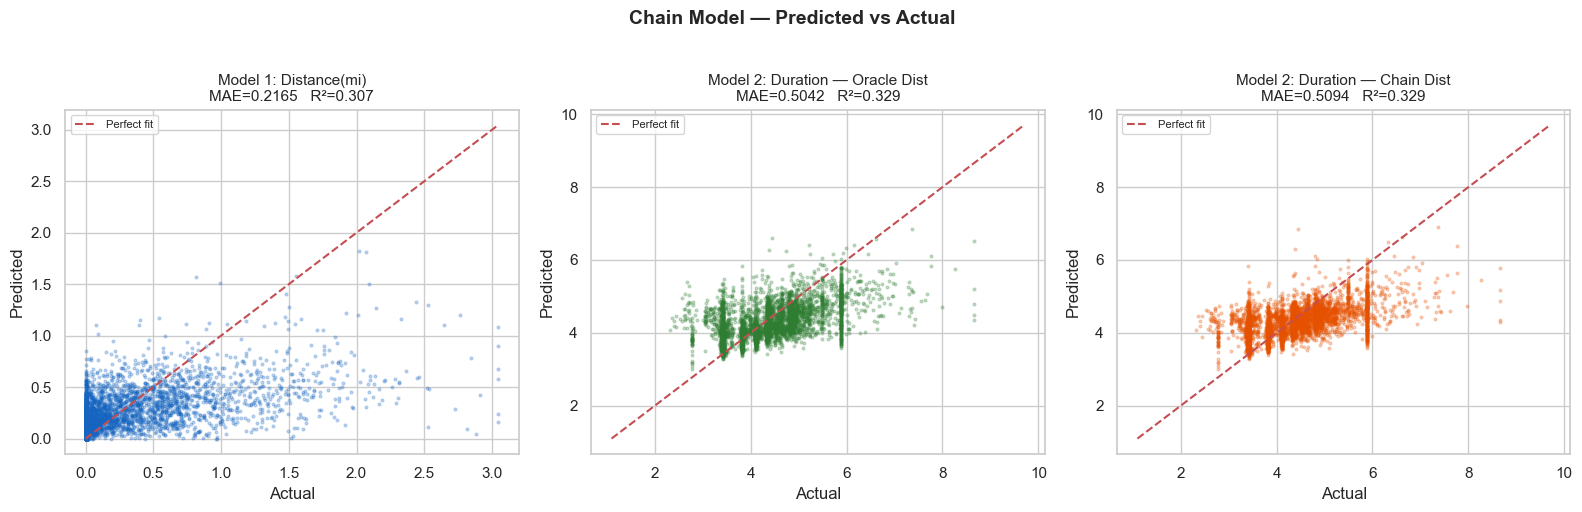

In [8]:
rng   = np.random.default_rng(42)
idx_s = rng.choice(len(y_val_d), min(5000, len(y_val_d)), replace=False)

def scatter_eval(ax, y_true, y_pred, title, color):
    ax.scatter(y_true.iloc[idx_s], y_pred[idx_s], alpha=0.25, s=4, color=color)
    lo = min(float(y_true.min()), float(y_pred.min()))
    hi = max(float(y_true.max()), float(y_pred.max()))
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    ax.set_title(f'{title}\nMAE={mae:.4f}   R²={r2:.3f}', fontsize=11)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
scatter_eval(axes[0], y_val_d, pred_d,            'Model 1: Distance(mi)',           '#1565C0')
scatter_eval(axes[1], y_val_t, pred_dur_oracle,   'Model 2: Duration — Oracle Dist', '#2E7D32')
scatter_eval(axes[2], y_val_t, pred_dur_chain,    'Model 2: Duration — Chain Dist',  '#E65100')
plt.suptitle('Chain Model — Predicted vs Actual', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

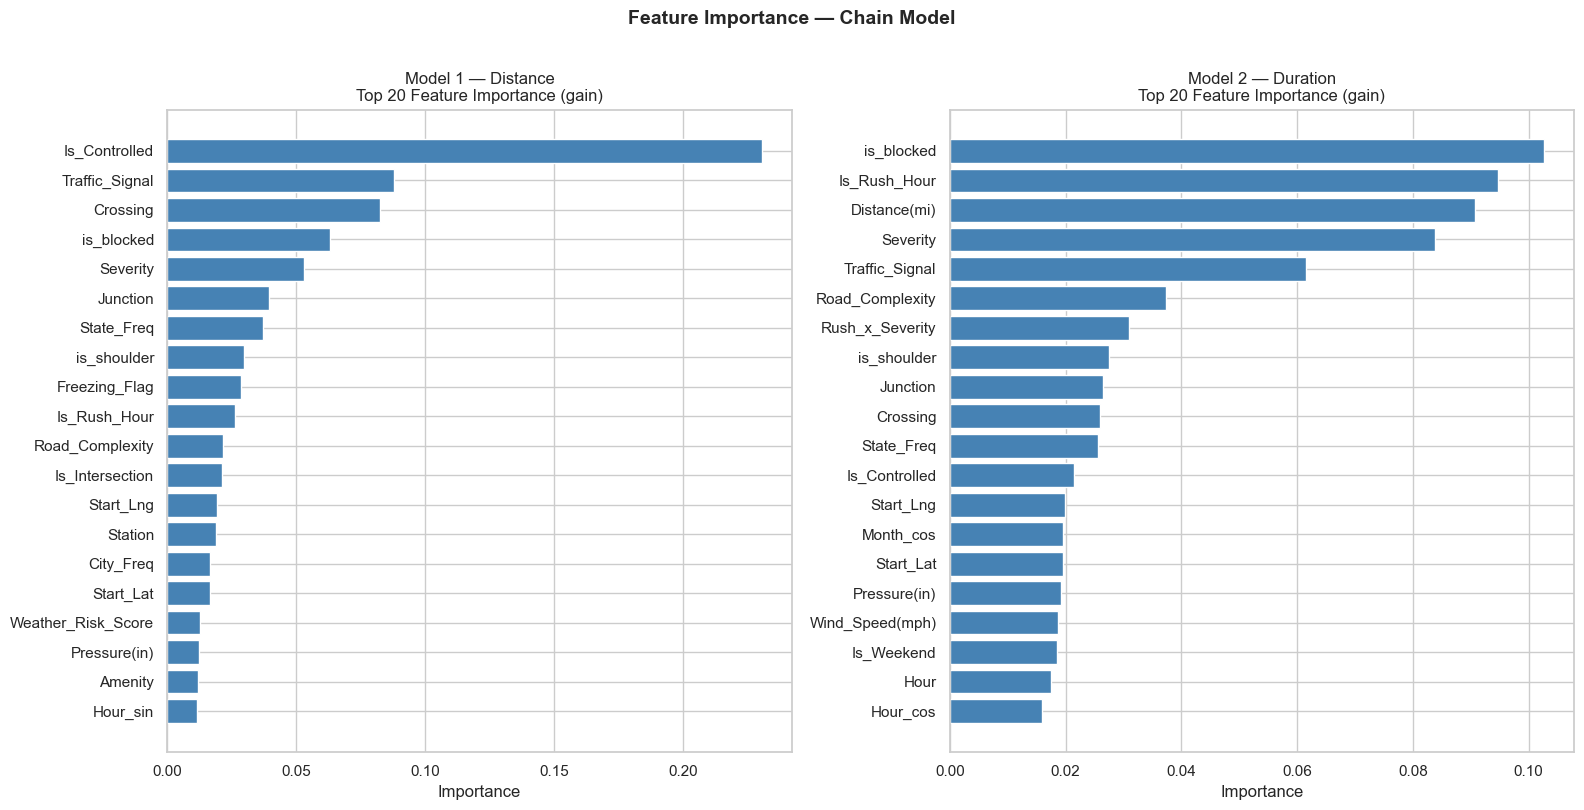

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for i, (ax, label, xgb_model, feat_list) in enumerate([
    (axes[0], 'Model 1 — Distance',  xgb_dist, num_features),
    (axes[1], 'Model 2 — Duration',  xgb_dur,  num_features_dur),
]):
    importance = pd.Series(xgb_model.feature_importances_, index=feat_list)
    top20 = importance.sort_values(ascending=False).head(20)
    ax.barh(top20.index[::-1], top20.values[::-1], color='steelblue', edgecolor='white')
    ax.set_title(f'{label}\nTop 20 Feature Importance (gain)', fontsize=12)
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance — Chain Model', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Save Models

In [10]:
os.makedirs("../models", exist_ok=True)

joblib.dump(model_dist, "../models/chain_dist_model.pkl")
joblib.dump(model_dur,  "../models/chain_dur_model.pkl")

# Save feature metadata for inference
metadata = {
    "base_features"    : base_features,
    "num_features"     : num_features,
    "num_features_dur" : num_features_dur,
    "target_dist"      : TARGET_DIST,
    "target_dur"       : TARGET_DUR,
    "use_log_target"   : USE_LOG_TARGET,    # inference must np.expm1 the output
    "n_oof_folds"      : N_OOF_FOLDS,
    "best_iter_dist"   : int(xgb_dist.best_iteration),
    "best_iter_dur"    : int(xgb_dur.best_iteration),
}
joblib.dump(metadata, "../models/chain_metadata.pkl")

print("Saved:")
print(f"  models/chain_dist_model.pkl   ({len(num_features)} features)")
print(f"  models/chain_dur_model.pkl    ({len(num_features_dur)} features)")
print(f"  models/chain_metadata.pkl     (use_log_target={USE_LOG_TARGET})")

# Final summary table
rows = [
    ["Distance", "—",   f"{mean_absolute_error(y_val_d, pred_d):.4f}",
                            f"{np.sqrt(mean_squared_error(y_val_d, pred_d)):.4f}",
                            f"{r2_score(y_val_d, pred_d):.4f}"],
    ["Duration", "Oracle",  f"{mean_absolute_error(y_val_t, pred_dur_oracle):.4f}",
                            f"{np.sqrt(mean_squared_error(y_val_t, pred_dur_oracle)):.4f}",
                            f"{r2_score(y_val_t, pred_dur_oracle):.4f}"],
    ["Duration", "Chain",   f"{mean_absolute_error(y_val_t, pred_dur_chain):.4f}",
                            f"{np.sqrt(mean_squared_error(y_val_t, pred_dur_chain)):.4f}",
                            f"{r2_score(y_val_t, pred_dur_chain):.4f}"],
]
print("\n=== Final Chain Model Summary ===")
print(pd.DataFrame(rows, columns=["Target","Mode","MAE","RMSE","R²"]).to_string(index=False))

# --- Side-by-side comparison vs prior run (hard-coded baseline from previous notebook execution) ---
baseline = {
    "Distance MAE":          0.2513,
    "Duration Oracle MAE":   0.4733,
    "Duration Chain MAE":    0.7565,
    "Distance R²":           0.2366,
    "Duration Oracle R²":    0.4092,
    "Duration Chain R²":    -0.2506,
}
new_vals = {
    "Distance MAE":          mean_absolute_error(y_val_d, pred_d),
    "Duration Oracle MAE":   mean_absolute_error(y_val_t, pred_dur_oracle),
    "Duration Chain MAE":    mean_absolute_error(y_val_t, pred_dur_chain),
    "Distance R²":           r2_score(y_val_d, pred_d),
    "Duration Oracle R²":    r2_score(y_val_t, pred_dur_oracle),
    "Duration Chain R²":    r2_score(y_val_t, pred_dur_chain),
}
cmp = pd.DataFrame({
    "Metric":   list(baseline),
    "Before":   [baseline[k]        for k in baseline],
    "After":    [new_vals[k]        for k in baseline],
})
cmp["Δ"] = cmp["After"] - cmp["Before"]
print("\n=== Improvement vs Previous Run ===")
print(cmp.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))


Saved:
  models/chain_dist_model.pkl   (45 features)
  models/chain_dur_model.pkl    (46 features)
  models/chain_metadata.pkl     (use_log_target=True)

=== Final Chain Model Summary ===
  Target   Mode    MAE   RMSE     R²
Distance      — 0.2165 0.3745 0.3067
Duration Oracle 0.5042 0.6969 0.3290
Duration  Chain 0.5094 0.6968 0.3292

=== Improvement vs Previous Run ===
             Metric  Before   After       Δ
       Distance MAE +0.2513 +0.2165 -0.0348
Duration Oracle MAE +0.4733 +0.5042 +0.0309
 Duration Chain MAE +0.7565 +0.5094 -0.2471
        Distance R² +0.2366 +0.3067 +0.0701
 Duration Oracle R² +0.4092 +0.3290 -0.0802
  Duration Chain R² -0.2506 +0.3292 +0.5798
